# sHū addi Smart Inventory Counter

## Project Overview

This proof of concept uses YOLO object detection to identify and count visible products in an image. The goal is to demonstrate how computer vision can support faster inventory checks by producing an annotated image and a simple count by detected class.

Because the pretrained YOLO model does not include custom apparel categories such as shirts, socks, and caps, this version uses supported object classes and documents the need for future fine-tuning on a labeled apparel dataset.

In [1]:
# Install and import the tools needed for the inventory counter
%pip install -q ultralytics

from ultralytics import YOLO
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup complete.


In [7]:
# Load the pretrained YOLO11 nano model
model = YOLO("yolo11n.pt")

print("YOLO11 model loaded successfully.")
print(f"The model recognizes {len(model.names)} object classes.")

YOLO11 model loaded successfully.
The model recognizes 80 object classes.


Saving ChatGPT Image Aug 15, 2025 at 05_22_02 PM.jpeg to ChatGPT Image Aug 15, 2025 at 05_22_02 PM.jpeg
Saving IMG_0660.jpeg to IMG_0660.jpeg
Saving ChatGPT Image Aug 15, 2025 at 05_45_26 PM.png to ChatGPT Image Aug 15, 2025 at 05_45_26 PM.png
Uploaded image: ChatGPT Image Aug 15, 2025 at 05_22_02 PM.jpeg


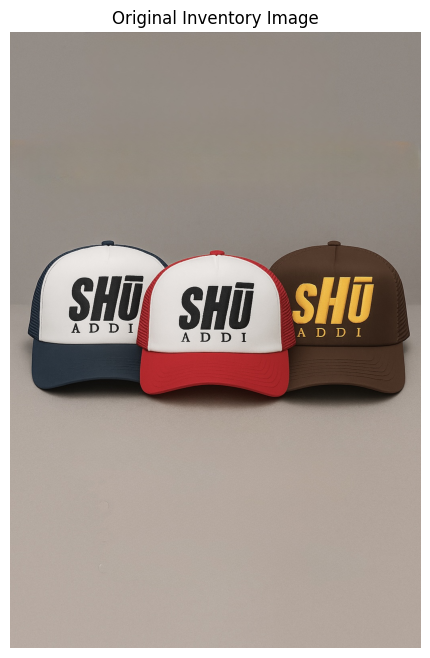

In [8]:
# Upload a product or retail-style image from your computer
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded))

print(f"Uploaded image: {image_path}")

# Display the original image
image = Image.open(image_path)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Original Inventory Image")
plt.show()


image 1/1 /content/ChatGPT Image Aug 15, 2025 at 05_22_02 PM.jpeg: 640x448 (no detections), 399.8ms
Speed: 14.8ms preprocess, 399.8ms inference, 19.0ms postprocess per image at shape (1, 3, 640, 448)


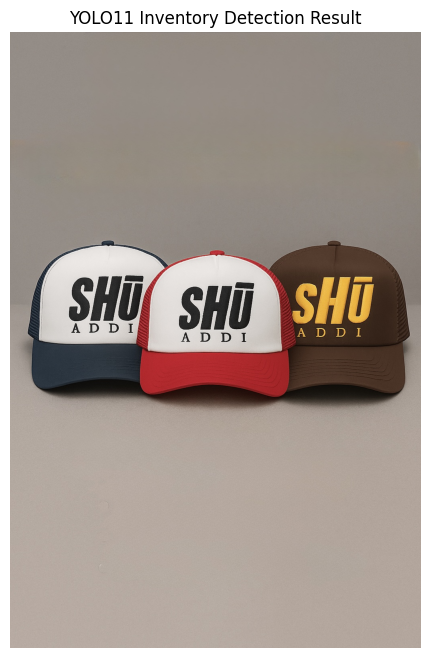

INVENTORY COUNT
No supported YOLO classes were detected.

Total detected objects: 0


In [9]:
# Run YOLO11 detection on the uploaded inventory image
results = model(image_path, conf=0.20)

# Display the annotated result
annotated = results[0].plot()[..., ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("YOLO11 Inventory Detection Result")
plt.show()

# Count every detected class
detected_names = [
    model.names[int(class_id)]
    for class_id in results[0].boxes.cls
]

inventory_counts = Counter(detected_names)

print("INVENTORY COUNT")
print("=" * 30)

if inventory_counts:
    for item, count in inventory_counts.items():
        print(f"{item}: {count}")
else:
    print("No supported YOLO classes were detected.")

print(f"\nTotal detected objects: {len(detected_names)}")


image 1/1 /content/IMG_8298.jpg: 640x640 2 suitcases, 273.2ms
Speed: 7.4ms preprocess, 273.2ms inference, 5.9ms postprocess per image at shape (1, 3, 640, 640)


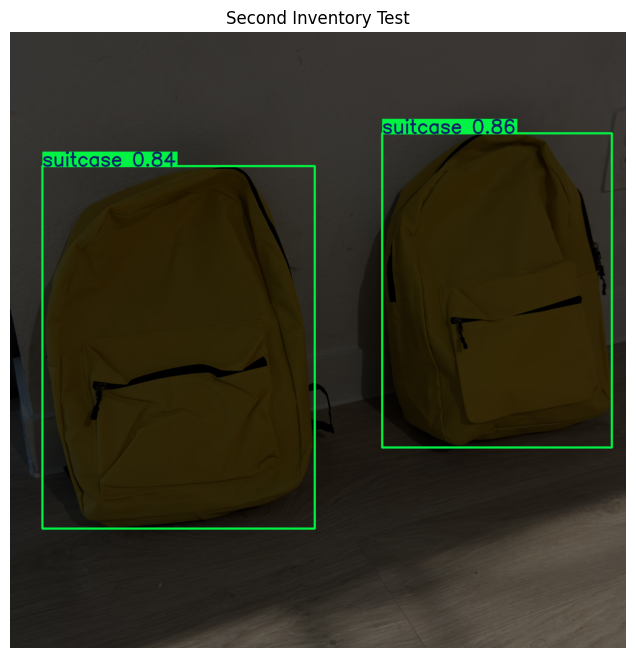

SECOND INVENTORY COUNT
suitcase: 2

Total detected objects: 2


In [15]:
# Test a second uploaded image that contains supported YOLO classes
test_image_path = "IMG_8298.jpg"

test_results = model(test_image_path, conf=0.20)

test_annotated = test_results[0].plot()[..., ::-1]

plt.figure(figsize=(10, 8))
plt.imshow(test_annotated)
plt.axis("off")
plt.title("Second Inventory Test")
plt.show()

test_detected_names = [
    model.names[int(class_id)]
    for class_id in test_results[0].boxes.cls
]

test_inventory_counts = Counter(test_detected_names)

print("SECOND INVENTORY COUNT")
print("=" * 30)

if test_inventory_counts:
    for item, count in test_inventory_counts.items():
        print(f"{item}: {count}")
else:
    print("No supported YOLO classes were detected.")

print(f"\nTotal detected objects: {len(test_detected_names)}")

## Test Results and Analysis

The first test used three sHū addi hats, but YOLO11 detected zero objects because hats are not included in its standard COCO classes. The second test used sHū addi socks, whick also produced zero detections for the same reason.

In the final test, YOLO11 detected and counted two backpacks. The object count was correct, but the model classified both backpacks as suitcases with confidence scores of 0.84 and 0.86. This shows that the general inventory counting workflow works, but a custom apparel dataset and model fine-tuning would be needed for accurate product labels such as hats, socks, shirts, and backpacks.

In [14]:
from google.colab import files

new_upload = files.upload()
test_image_path = next(iter(new_upload))

print(f"New test image uploaded: {test_image_path}")

Saving IMG_8298.jpg to IMG_8298.jpg
New test image uploaded: IMG_8298.jpg


In [16]:
# Summarize the three inventory tests

test_summary = {
    "Hats": {"actual": 3, "detected": 0, "label_result": "Not detected"},
    "Socks": {"actual": 4, "detected": 0, "label_result": "Not detected"},
    "Backpacks": {"actual": 2, "detected": 2, "label_result": "Misclassified as suitcases"}
}

print("FINAL TEST SUMMARY")
print("=" * 65)

for item, result in test_summary.items():
    print(
        f"{item:<12} "
        f"Actual: {result['actual']} | "
        f"Detected: {result['detected']} | "
        f"Result: {result['label_result']}"
    )

total_actual = sum(result["actual"] for result in test_summary.values())
total_detected = sum(result["detected"] for result in test_summary.values())

count_recall = total_detected / total_actual

print("\nOverall object-count recall:")
print(f"{total_detected} of {total_actual} products detected = {count_recall:.1%}")

FINAL TEST SUMMARY
Hats         Actual: 3 | Detected: 0 | Result: Not detected
Socks        Actual: 4 | Detected: 0 | Result: Not detected
Backpacks    Actual: 2 | Detected: 2 | Result: Misclassified as suitcases

Overall object-count recall:
2 of 9 products detected = 22.2%


## Conclusion

The proof of concept successfully demonstrated the full workflow of an automated inventory counter: an image was uploaded, YOLO11 processed the image, detections were displayed, and the system generated an automatic count.

Across the three tests, the system detected 2 of 9 visible products, producing an overall object-count recall of 22.2%. The low result occurred because the pretrained model was not trained for the custom apparel categories used in the project. The backpack test showed that the system could locate and count two objects correctly, even though both were mislabeled as suitcases.

The next version would use a custom labeled dataset containing sHū addi hats, socks, shirts, and backpacks. Fine-tuning YOLO11 on those classes should improve both the product count and the accuracy of the class labels.